## Bibliotecas e GPU

In [27]:
# Bibliotecas
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from funcs import modificacoes1, banco, tvt, modificacoes2
from redes.unet import unet 
from redes.ResUnet import MultiResUnet


import tensorflow as tf
from tensorflow import keras
from keras import mixed_precision
from keras.callbacks import EarlyStopping


In [28]:
# Configuração (GPU / mixed precision / strategy)

print('TensorFlow:', tf.__version__)
print('Built with CUDA:', tf.test.is_built_with_cuda())

gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print('GPUs:', gpus)
print('CPUs:', cpus)

# Importante: fazer isso ANTES de criar modelos/estratégias, para evitar reservar toda a VRAM
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception as e:
            print('Não foi possível habilitar memory growth:', e)

    # Mixed precision costuma reduzir MUITO o uso de VRAM em U-Net
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision policy:', mixed_precision.global_policy())

# Estratégia: só use MirroredStrategy se tiver >1 GPU
strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()
print('Strategy:', type(strategy).__name__)

TensorFlow: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">
Strategy: _DefaultDistributionStrategy


## Criando o banco de dados

In [3]:
""" Renomeia os arquivos do label_studio """
# path_y_train = 'banco2/Nelore2/label_studio'
# path_x_train = 'banco2/Nelore2/img_corte'
# y_destino = 'banco2/Nelore2/label_egl'
# lista_img_train = sorted(os.listdir(path_x_train))
# lista_img_label = sorted(os.listdir(path_y_train))
# print(lista_img_label)

# for i,nome_arquivo in enumerate(lista_img_label):
#     caminho = os.path.join(path_y_train, nome_arquivo)
#     img = cv2.imread(caminho)

#     nome_limpo, ext = os.path.splitext(lista_img_train[i])
#     novo_nome = f'{nome_limpo}.jpg'
#     destino = os.path.join(y_destino, novo_nome)
#     cv2.imwrite(destino, img)

' Renomeia os arquivos do label_studio '

In [7]:
path_x_train = 'banco2/TreinoGeral/EGL/imgs'
path_y_train = 'banco2/TreinoGeral/EGL/labels'

x_train, nomes_train = banco(path_x_train, resolution=(256,256), grayscale= True, nomes=True)
y_train, labels_train = banco(path_y_train, resolution=(256,256), grayscale= True, nomes=True)

print(f'Tamanho x_train: {x_train.shape}, y_train: {y_train.shape}')

Tamanho x_train: (135, 256, 256, 1), y_train: (135, 256, 256, 1)


In [4]:
""" Visualizando algumas imagens e labels """
def plot_img_mask(img_list, mask_list, num_pairs = 5, label = None):
    n = num_pairs
    plt.figure(figsize=(10, 6))
    for i in range(n):
        idx = random.randint(0, len(img_list) - 1)
        img = img_list[idx]
        mask = mask_list[idx]
        plt.subplot(2, n, i + 1)
        plt.imshow(img)
        if label is not None and len(label) > idx:
            plt.title(f"Imagem = {label[idx][2:6]}, index =  {idx}", fontsize=9)
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(mask)
        if label is not None and len(label) > idx:
            plt.title(f"Label = {label[idx][2:6]}, index = {idx}", fontsize=9)
        plt.axis("off")
        del img, mask

In [8]:
""" Função tvt: train, val, test """
x_train, y_train, nomes_train, x_val, y_val, nomes_val, x_test, y_test, nomes_test = tvt(x_train, y_train, partition=(0.7, 0.2, 0.1), nomes = labels_train) # 70% treino, 20% validação, 10% teste

In [9]:
# Prints de verificação dos conjuntos
print(f'Imagens X treino: {x_train.shape}')
print(f'Imagens Y treino: {y_train.shape}')
print(f'Nomes treino: {len(nomes_train)}')

print(f'Imagens X teste: {x_test.shape}')
print(f'Imagens Y teste: {y_test.shape}')
print(f'Nomes teste: {len(nomes_test)}')

print(f'Imagens X validação: {x_val.shape}')
print(f'Imagens Y validação: {y_val.shape}')
print(f'Nomes validação: {len(nomes_val)}')

Imagens X treino: (94, 256, 256, 1)
Imagens Y treino: (94, 256, 256, 1)
Nomes treino: 94
Imagens X teste: (14, 256, 256, 1)
Imagens Y teste: (14, 256, 256, 1)
Nomes teste: 14
Imagens X validação: (27, 256, 256, 1)
Imagens Y validação: (27, 256, 256, 1)
Nomes validação: 27


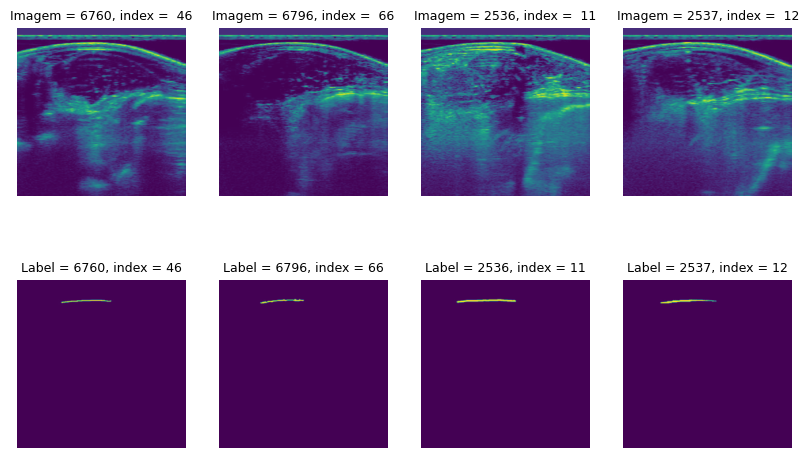

In [10]:
# Plot da função
plot_img_mask(x_train, y_train, num_pairs= 4, label= labels_train)

In [13]:
""" Modifica o banco de dados"""
# x_train
# Função para fazer as modificações nas imagens
dict_x_train, x_train_m = modificacoes1(x_train, 
             nomes_train, 
             original = True, 
             brilho = 1.7,
             escura= 0.5,
             rotacao=[-30,30])

dict_x_val, x_val_m = modificacoes1(x_val,
             nomes_val,
             original = True, 
             brilho = 1.7,
             escura= 0.5,
             rotacao=[-30,30])

print(f'Quantidade de chaves em dict_x_train: {len(dict_x_train.keys())}')
print(f'Quantidade de valores em dict_x_train: {len(dict_x_train.values())}')

Quantidade de chaves em dict_x_train: 376
Quantidade de valores em dict_x_train: 376


In [14]:
# Modificando as labels
y_train_m = dict(zip(nomes_train, y_train))
y_val_m = dict(zip(nomes_val, y_val))
print(f'Quantidade de chaves em y_train: {len(y_train_m)}')   
print(f'Quantidade de chaves em y_val: {len(y_val_m)}')

Quantidade de chaves em y_train: 94
Quantidade de chaves em y_val: 27


In [15]:
# # # y_train
## duplica imagens de label se necessario
y_train_m, y_train_nomes = modificacoes2(y_train_m, dict_x_train.keys())
y_val_m, y_val_nomes = modificacoes2(y_val_m, dict_x_val.keys())

In [16]:
x_train_m = np.array(x_train_m)
y_train_m = np.array(y_train_m)

x_val_m = np.array(x_val_m)
y_val_m = np.array(y_val_m)

In [17]:
print(f"Quantidade de imagens em x_train_modificado: {x_train_m.shape}")
print(f"Quantidade de imagens em y_train_modificado: {y_train_m.shape}")

print(f"Quantidade de imagens em x_val_modificado: {x_val_m.shape}")
print(f"Quantidade de imagens em y_val_modificado: {y_val_m.shape}")

Quantidade de imagens em x_train_modificado: (376, 256, 256, 1)
Quantidade de imagens em y_train_modificado: (376, 256, 256, 1)
Quantidade de imagens em x_val_modificado: (108, 256, 256, 1)
Quantidade de imagens em y_val_modificado: (108, 256, 256, 1)


## Salvando x_teste para testes futuros

In [18]:
# Pasta base de saída
out_base = "banco2/TreinoGeral/EGL/validacaoGeral"
out_x = os.path.join(out_base, "x_test")
out_y = os.path.join(out_base, "y_test")
os.makedirs(out_x, exist_ok=True)
os.makedirs(out_y, exist_ok=True)

def to_uint8(img):
    """Converte imagem para uint8 [0,255], tratando float/bool e canal único."""
    arr = np.squeeze(img)  # remove canal extra (H,W,1) -> (H,W)
    if arr.dtype == np.bool_:
        arr = arr.astype(np.uint8) * 255
    elif np.issubdtype(arr.dtype, np.floating):
        # Se estiver normalizada em [0,1], escala para [0,255]
        arr = np.clip(arr, 0, 1)
        arr = (arr * 255).astype(np.uint8)
    else:
        arr = arr.astype(np.uint8)
    return arr

for i in range(len(x_test)):
    nome_base = nomes_test[i] if "nomes_test" in globals() and i < len(nomes_test) else f"img_{i:04d}"
    nome_base = os.path.splitext(os.path.basename(str(nome_base)))[0]

    img_x = to_uint8(x_test[i])
    img_y = to_uint8(y_test[i])

    cv2.imwrite(os.path.join(out_x, f"{nome_base}.jpg"), img_x)
    cv2.imwrite(os.path.join(out_y, f"{nome_base}.jpg"), img_y)

print(f"Salvo em: {os.path.abspath(out_base)}")
print(f"Total de pares salvos: {len(x_test)}")

Salvo em: /home/victors/Documents/Codigos_Mestrado/banco2/TreinoGeral/EGL/validacaoGeral
Total de pares salvos: 14


## Métricas & Funções

In [19]:
# Converting the arrays into tf.data batches (mais leve e eficiente)
import gc
AUTOTUNE = tf.data.AUTOTUNE

# Se ainda der OOM, o 1o ajuste e reduzir batch_size
batch_size = 1

In [20]:
""" setting DICE coefficient to evaluate the model """
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Flatten per-sample to compute Dice over all pixels
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)
    dice_coeff = (2.0 * intersection + smooth) / (union + smooth)
    return dice_coeff

In [21]:
""" setting DICE loss to train the model"""

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

In [22]:
""" Função: calcular área (predição vs máscara) na dimensão original (403x333) """
def comparar_area_predicao(
    idx,
    model,
    x_imgs,
    y_masks,
    nomes_dados = None,
    orig_size=(403, 333),
    threshold=0.5,
    px_per_cm=24.05,
    smooth=1e-6,
    plot=False,
    overlay_alpha=0.35,
    contours=True,
    verbose=True,
 ):
    orig_h, orig_w = orig_size  # (H, W)
    cm_per_px = 1.0 / px_per_cm 
    # Pega amostra
    x = x_imgs[idx]
    y_true = y_masks[idx]
    # Predição (probabilidade)
    x_in = tf.expand_dims(x, axis=0)
    y_pred = model.predict(x_in, verbose=0)
    y_pred = np.squeeze(y_pred)
    # Binariza
    y_pred_bin = (y_pred >= threshold).astype(np.uint8)
    y_true = np.squeeze(y_true)
    # Se a máscara veio como 0..255, normaliza implicitamente via threshold
    y_true_bin = (y_true >= threshold).astype(np.uint8)
    # Garante 2D
    if y_pred_bin.ndim == 3:
        y_pred_bin = np.squeeze(y_pred_bin)
    if y_true_bin.ndim == 3:
        y_true_bin = np.squeeze(y_true_bin)
    # Resize para dimensão original (OpenCV usa (W,H))
    pred_orig = cv2.resize(y_pred_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST_EXACT)
    true_orig = cv2.resize(y_true_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST_EXACT)
    # Áreas (px²) e (cm²)
    
    # Diametro vertical (de cima para baixo) na dimensão original
    def _diametro_vertical(mask: np.ndarray) -> int:
        max_len = 0
        # best_col = -1
        # best_row_start = -1

        rows, cols = mask.shape

        for col in range(cols):
            current_len = 0
            row_start = -1
            for row in range(rows):
                if mask[row, col] == 1:
                    if current_len == 0:
                        row_start = row
                    current_len += 1

                    if current_len > max_len:
                        max_len = current_len
                        # best_col = col
                        # best_row_start = row_start
                else:
                    current_len = 0
        return max_len
    
    

    diam_pred_px = _diametro_vertical(pred_orig)
    diam_true_px = _diametro_vertical(true_orig)
    
    diam_pred_cm = diam_pred_px * cm_per_px
    diam_true_cm = diam_true_px * cm_per_px
    diam_diff_px = np.abs(diam_pred_px - diam_true_px)
    diam_diff_cm = np.abs(diam_diff_px * cm_per_px)
    # Métricas na dimensão original
    intersection = int((pred_orig & true_orig).sum())
    union = int((pred_orig | true_orig).sum())

    iou = (intersection + smooth) / (union + smooth)
    result = {
        'idx': idx,
        'orig_size': (orig_h, orig_w),
        'threshold': float(threshold),
        'px_per_cm': float(px_per_cm),
        'diam_pred_px': int(diam_pred_px),
        'diam_true_px': int(diam_true_px),
        'diam_pred_cm': float(diam_pred_cm),
        'diam_true_cm': float(diam_true_cm),
        'diam_diff_px': int(diam_diff_px),
        'diam_diff_cm': float(diam_diff_cm),
        'iou_orig': float(iou),
    }
    if verbose:
        print(
            f"diam_true={diam_true_cm:.3f} cm | diam_pred={diam_pred_cm:.3f} cm | "
            f"diam_diff={diam_diff_cm:+.3f} cm | "
        )
    if plot:
        img = np.squeeze(x)
        # Mostra na dimensão do modelo (p/ referência) e overlays na dimensão original
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(img, cmap='gray')
        if nomes_dados is not None and len(nomes_dados) > idx:
            plt.title(f'Imagem (modelo) idx={idx} | {nomes_dados[idx][2:6]}')
        else:
            plt.title(f'Imagem (modelo) idx={idx}')
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.imshow(true_orig, cmap='gray')
        plt.title(f'Máscara verdadeira (orig {orig_h}x{orig_w})')
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.imshow(pred_orig, cmap='gray')
        plt.title(f'Máscara predita (orig {orig_h}x{orig_w})')
        plt.axis('off')
        plt.show()
        # Overlay (opcional)
        plt.figure(figsize=(7, 7))
        plt.imshow(cv2.resize(img, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR), cmap='gray') # Plano de fundo
        plt.imshow(true_orig, cmap='Reds', alpha=overlay_alpha, vmin=0, vmax=1)
        plt.imshow(pred_orig, cmap='Blues', alpha=overlay_alpha, vmin=0, vmax=1)
        if contours:
            try:
                plt.contour(true_orig, levels=[0.5], colors='red', linewidths=1)
                plt.contour(pred_orig, levels=[0.5], colors='deepskyblue', linewidths=1)
            except Exception:
                pass
        plt.title(f'Overlay (orig) idx={idx} | true=vermelho | pred=azul')
        plt.axis('off')
        plt.show()
    return result

## Modelo

In [23]:
shuffle_buffer = min(256, len(x_train_m))

# Evita float64 acidental em RAM
x_train_m = x_train_m.astype(np.float32, copy=False)
y_train_m = y_train_m.astype(np.float32, copy=False)
x_val_m = x_val_m.astype(np.float32, copy=False)
y_val_m = y_val_m.astype(np.float32, copy=False)
x_val = x_val.astype(np.float32, copy=False)
y_val = y_val.astype(np.float32, copy=False)

train_data = tf.data.Dataset.from_tensor_slices((x_train_m, y_train_m))
train_data = train_data.shuffle(buffer_size=shuffle_buffer, seed=42, reshuffle_each_iteration=True)
train_data = train_data.batch(batch_size).prefetch(AUTOTUNE)

val_data = tf.data.Dataset.from_tensor_slices((x_val_m, y_val_m))
val_data = val_data.batch(batch_size).prefetch(AUTOTUNE)

test_data = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_data = test_data.batch(batch_size).prefetch(AUTOTUNE)





I0000 00:00:1773790530.086057  182119 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1666 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [24]:
# Libera copias grandes da CPU RAM
del x_train, y_train, x_test, y_test, labels_train
del nomes_train, nomes_test, y_train_nomes, y_val_nomes
del dict_x_train, dict_x_val, x_train_m, y_train_m, x_val_m, y_val_m
gc.collect()

16855

In [29]:
""" U-net """
tf.keras.backend.clear_session()
gc.collect()

# Garante que o modelo segue o shape real dos dados
input_shape = tuple(x_val.shape[1:])  # (H, W, C)

with strategy.scope():
    # Modelo menor para caber na GPU (tente 32; se ainda der OOM, use 16)
    unet = unet(input_shape=input_shape, base_filters=64, max_filters=512)
    unet.compile(
        loss='binary_crossentropy',
        optimizer='adam', # Taxa de aprendizado padrão é de 0.001
        metrics=[dice_coefficient],
    )
unet.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 27,548,993 (105.09 MB)

 Trainable params: 27,548,993 (105.09 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
""" Defining early stopping callback """
early_stopping = EarlyStopping(monitor='val_dice_coefficient', patience=20, restore_best_weights=True, mode='max')

## Treino

In [31]:
unet_history = unet.fit(
    train_data,
    validation_data=val_data,
    epochs=200,
    callbacks=[early_stopping],
)

# Save the model
unet.save('modelos/unet_model_EGL_Geral.keras')

Epoch 1/200


I0000 00:00:1773790654.263445  190270 service.cc:153] XLA service 0x7f00c4045a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773790654.263497  190270 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1773790654.525527  190270 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773790656.676990  190270 cuda_dnn.cc:461] Loaded cuDNN version 92000
W0000 00:00:1773790659.217360  191490 hlo_rematerialization.cc:3204] Can't reduce memory use below 2.79GiB (2991887483 bytes) by rematerialization; only reduced to 4.07GiB (4367450144 bytes), down from 4.07GiB (4367450144 bytes) originally
W0000 00:00:1773790669.426996  190270 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.07GiB (rounded to 4366270976)requested

  1/376 ━━━━━━━━━━━━━━━━━━━━ 20:43:40 199s/step - dice_coefficient: 0.0094 - loss: 0.6969

I0000 00:00:1773790846.064125  190270 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_17', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_1', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1773790846.101177  190270 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


376/376 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - dice_coefficient: 0.0215 - loss: 0.0637

W0000 00:00:1773790875.289261  194366 hlo_rematerialization.cc:3204] Can't reduce memory use below 2.79GiB (2993959572 bytes) by rematerialization; only reduced to 4.07GiB (4371021856 bytes), down from 4.07GiB (4371021856 bytes) originally
W0000 00:00:1773790885.433158  190272 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.06GiB (rounded to 4362633728)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1773790885.433242  190272 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1773790885.433247  190272 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 94, Chunks in use: 94. 23.5KiB allocated for chunks. 23.5KiB in use in bin. 6.5KiB client-requested in use in bin.
I0000 00:00:1773790885.433255  190272 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 20, C

376/376 ━━━━━━━━━━━━━━━━━━━━ 315s 311ms/step - dice_coefficient: 0.0685 - loss: 0.0265 - val_dice_coefficient: 0.1509 - val_loss: 0.0123
Epoch 2/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - dice_coefficient: 0.2732 - loss: 0.0103 - val_dice_coefficient: 0.3538 - val_loss: 0.0099
Epoch 3/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - dice_coefficient: 0.3484 - loss: 0.0095 - val_dice_coefficient: 0.4151 - val_loss: 0.0094
Epoch 4/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - dice_coefficient: 0.3849 - loss: 0.0090 - val_dice_coefficient: 0.4460 - val_loss: 0.0147
Epoch 5/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - dice_coefficient: 0.4120 - loss: 0.0087 - val_dice_coefficient: 0.4638 - val_loss: 0.0086
Epoch 6/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - dice_coefficient: 0.4268 - loss: 0.0083 - val_dice_coefficient: 0.4762 - val_loss: 0.0084
Epoch 7/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - dice_coefficient: 0.4303 - loss: 0.0081 - val_dice_coefficient: 0.4128 

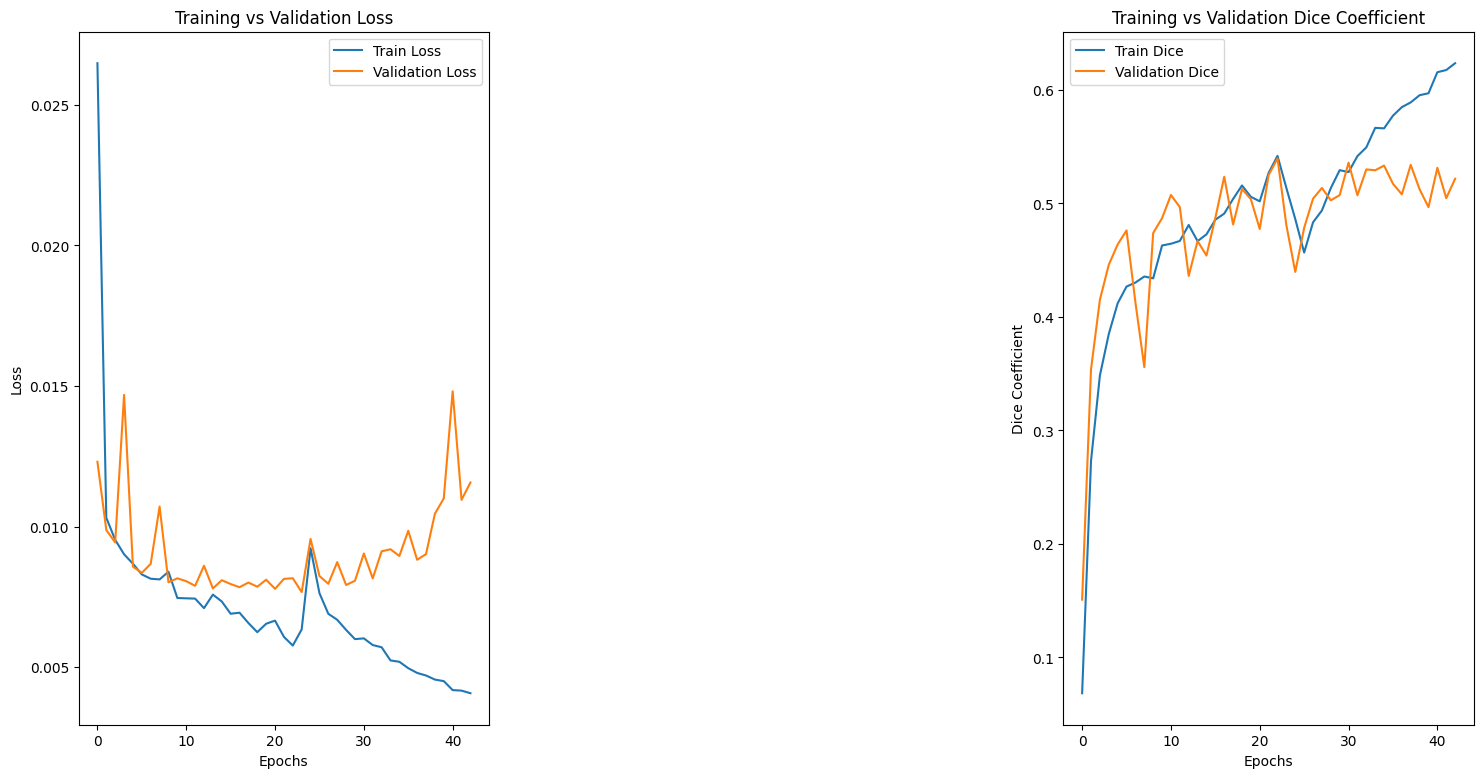

In [33]:
""" plotting the loss and accuracy during training and validation """
plt.figure(figsize=(18, 9))
plt.subplot(1, 3, 1)
plt.plot(unet_history.history['loss'])
plt.plot(unet_history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
# plt.subplot(1, 3, 2)
# plt.plot(unet_history.history['accuracy'])
# plt.plot(unet_history.history['val_accuracy'])
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.title('Training vs Validation Accuracy')
# plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.subplot(1, 3, 3)
plt.plot(unet_history.history['dice_coefficient'])
plt.plot(unet_history.history['val_dice_coefficient'])
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.title('Training vs Validation Dice Coefficient')
plt.legend(['Train Dice', 'Validation Dice'])

## Apaga alguns dados da memória

In [34]:
del unet_history
del train_data, test_data
del unet
gc.collect()

11885

## Carrega Modelo

In [35]:
""" Carregando o modelo salvo """
modelo = keras.models.load_model('modelos//unet_model_EGL_Geral.keras', custom_objects={'dice_coefficient': dice_coefficient, 'dice_loss': dice_loss})

## Testando com outros dados

In [36]:
""" Testando outras imagens """
path_x_new = 'banco2/TreinoGeral/EGL/validacaoGeral/x_test/'
path_y_new = 'banco2/TreinoGeral/EGL/validacaoGeral/y_test/'

x_new, nomes_x_new = banco(path_x_new, resolution=(256,256), grayscale= True, nomes= True)
y_new, nomes_y_new = banco(path_y_new, resolution=(256,256), grayscale= True, nomes= True)

dict_x_new, x_new_mod = modificacoes1(x_new,
             nomes_x_new,
             original = True,
             brilho = 1.7,
             escura= 0.5)

y_new_m, y_new_nomes = modificacoes2(dict(zip(nomes_y_new, y_new)), dict_x_new.keys())


x_new_m = np.array(x_new_mod)
y_new_m = np.array(y_new_m)


print(f'Novas imagens : {x_new_m.shape}')
print(f'Novos rótulos : {y_new_m.shape}')

new_data = tf.data.Dataset.from_tensor_slices((x_new_mod, y_new_m))
new_data = new_data.batch(batch_size).prefetch(AUTOTUNE)
modelo.evaluate(new_data, verbose= 1)

Novas imagens : (42, 256, 256, 1)
Novos rótulos : (42, 256, 256, 1)
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - dice_coefficient: 0.5949 - loss: 0.0044


[0.004380304366350174, 0.594881534576416]

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | 


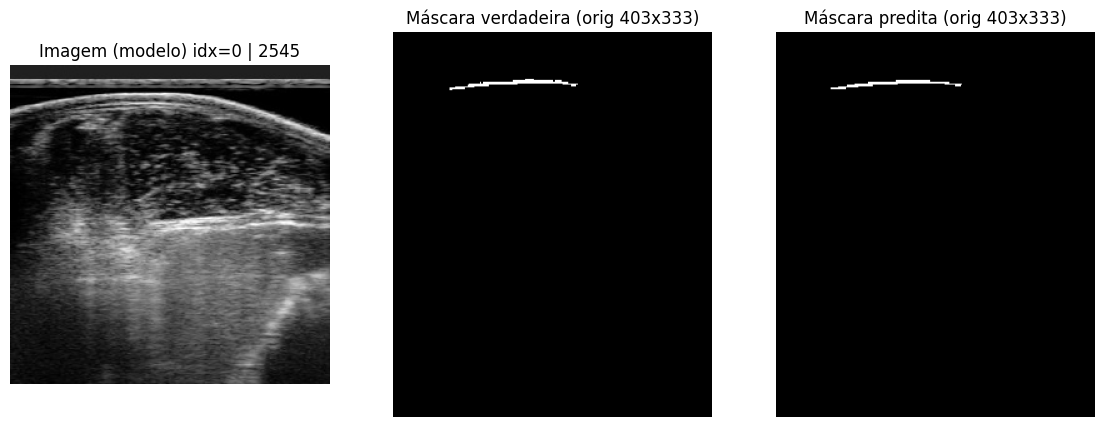

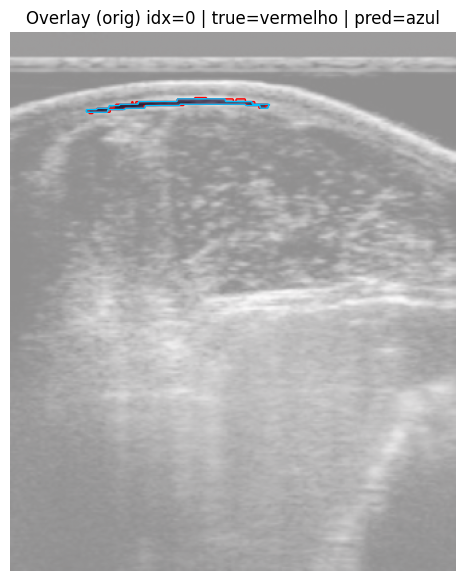

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | 


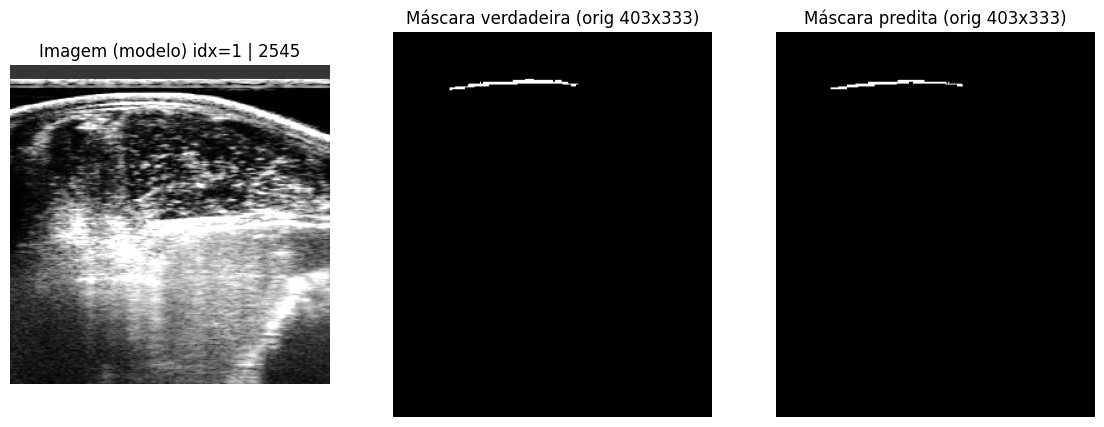

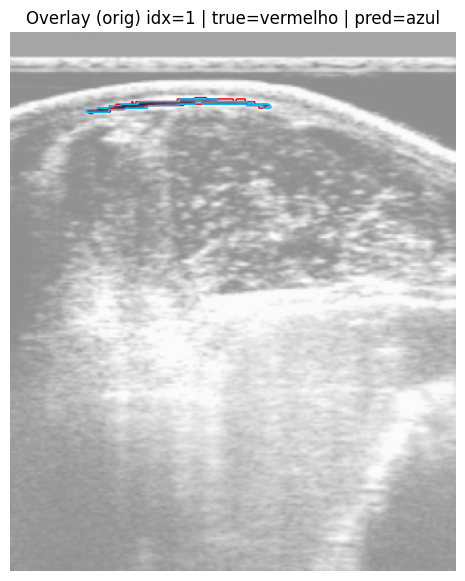

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | 


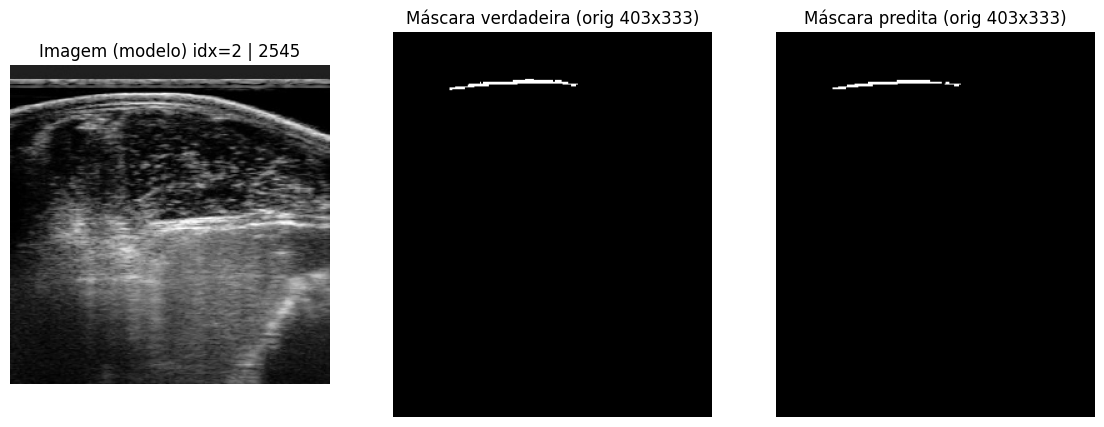

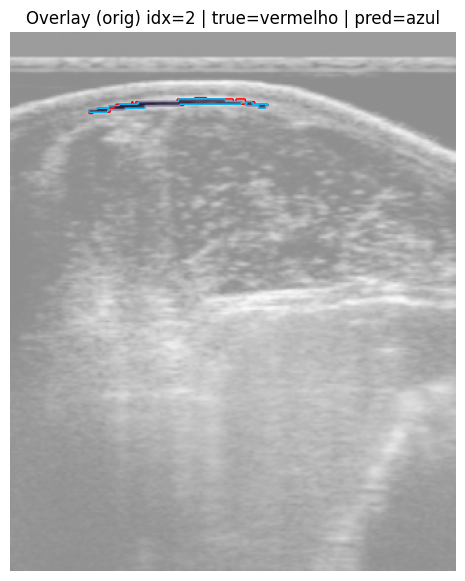

diam_true=0.249 cm | diam_pred=0.249 cm | diam_diff=+0.000 cm | 


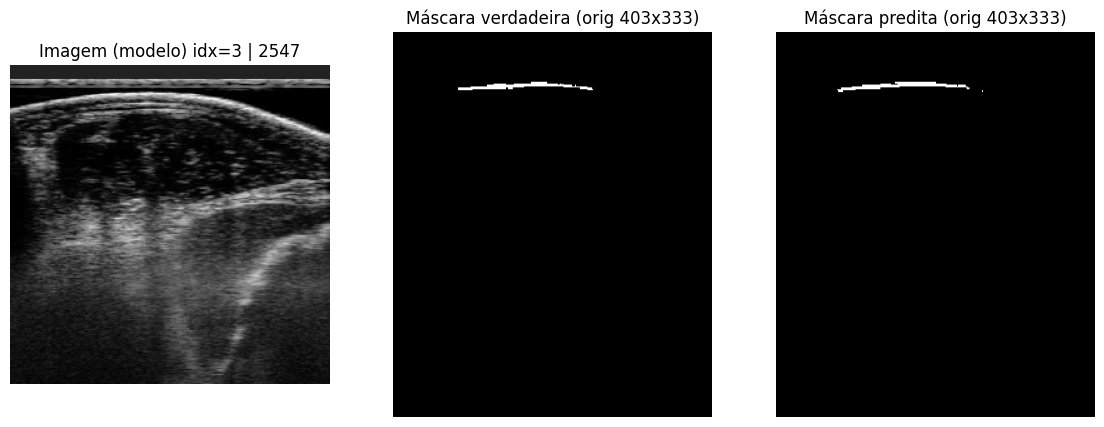

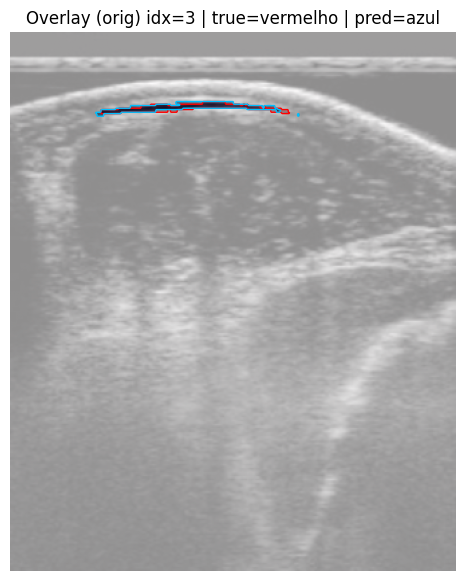

diam_true=0.249 cm | diam_pred=0.333 cm | diam_diff=+0.083 cm | 


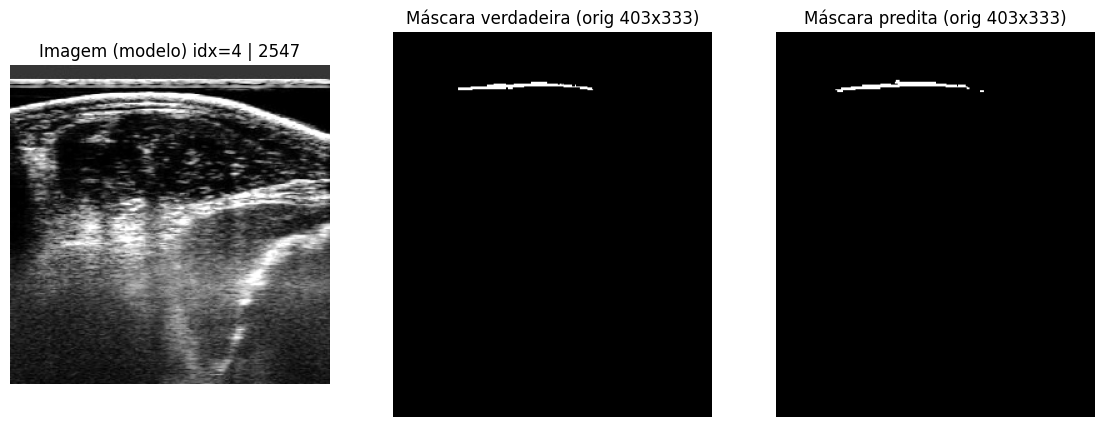

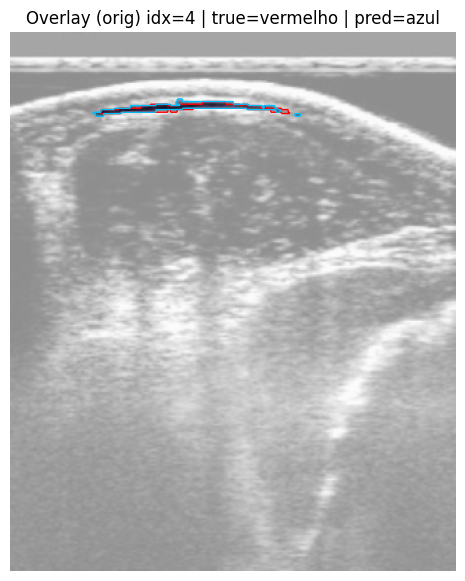

diam_true=0.249 cm | diam_pred=0.249 cm | diam_diff=+0.000 cm | 


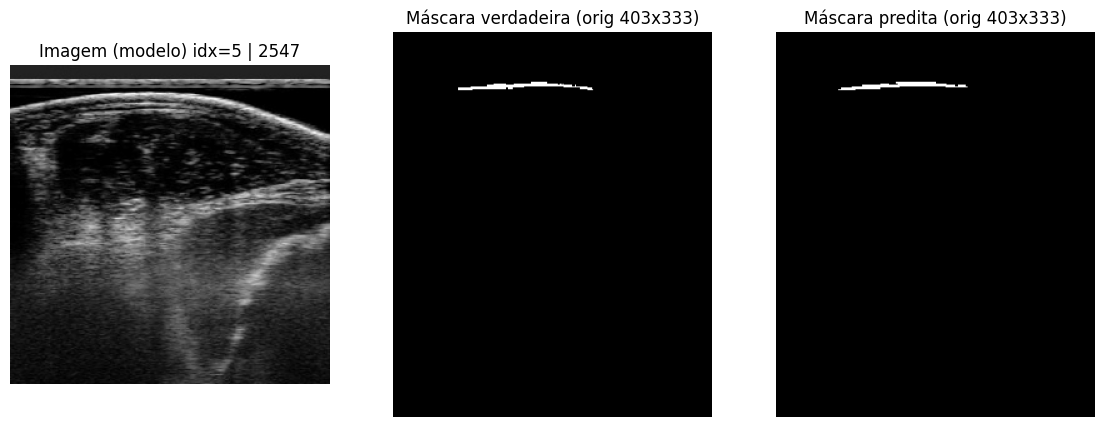

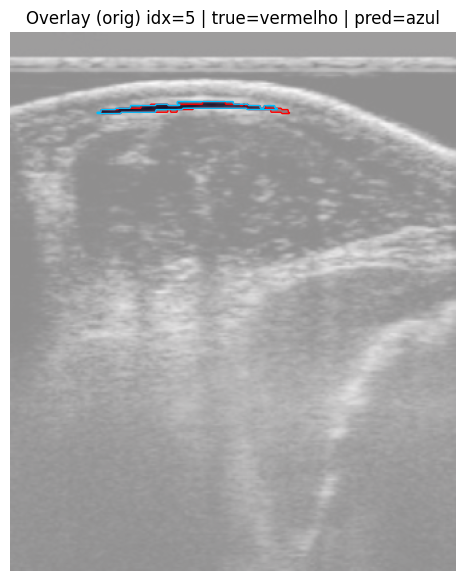

diam_true=0.208 cm | diam_pred=0.125 cm | diam_diff=+0.083 cm | 


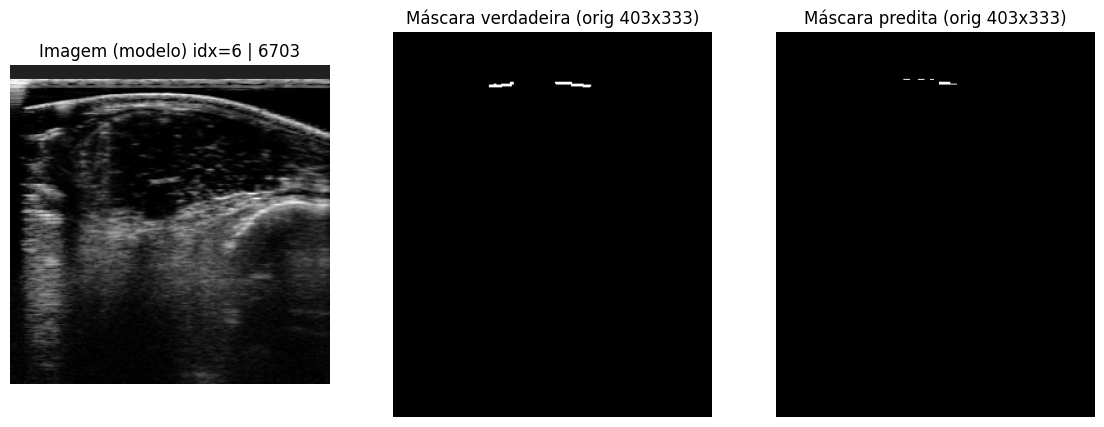

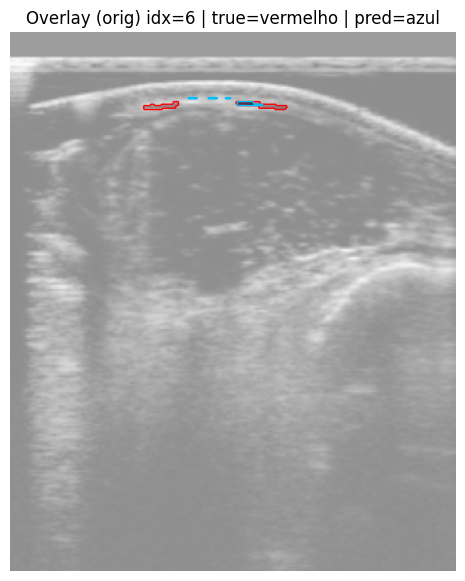

diam_true=0.208 cm | diam_pred=0.125 cm | diam_diff=+0.083 cm | 


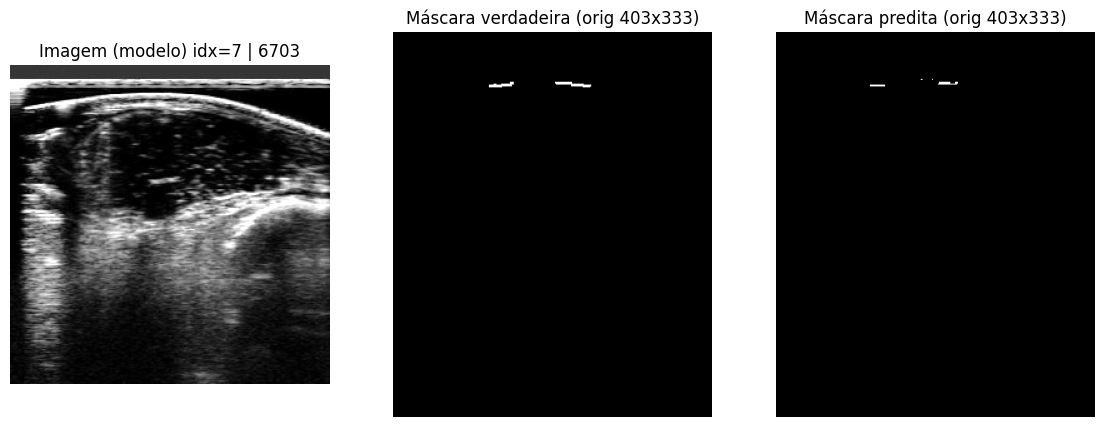

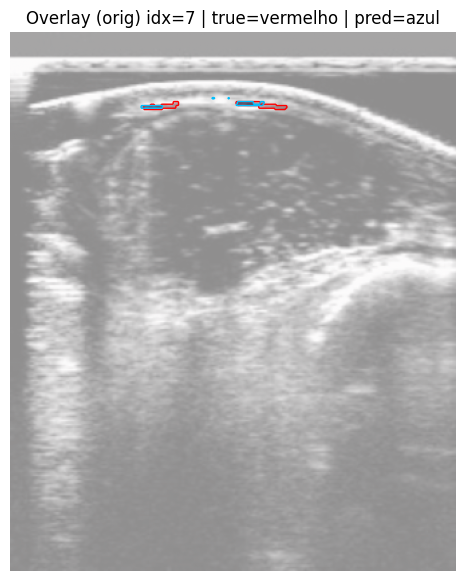

diam_true=0.208 cm | diam_pred=0.125 cm | diam_diff=+0.083 cm | 


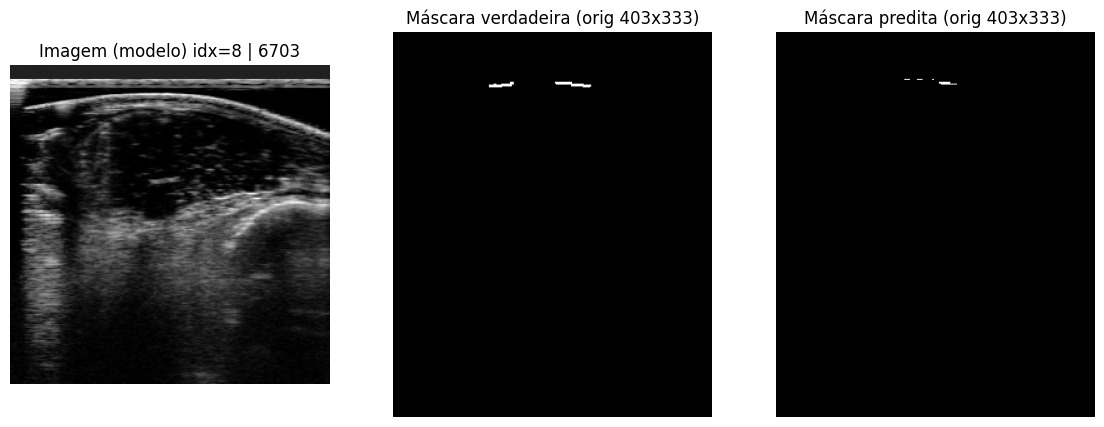

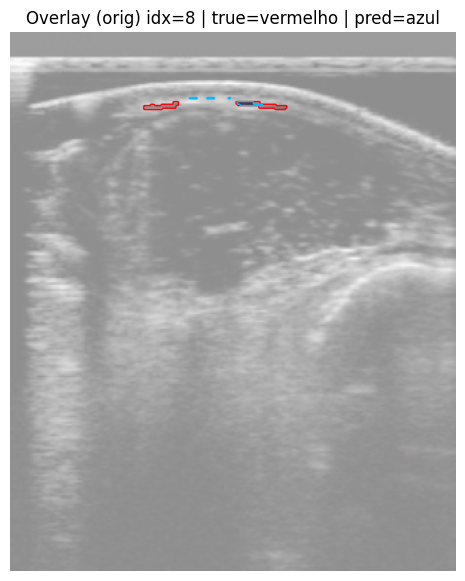

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | 


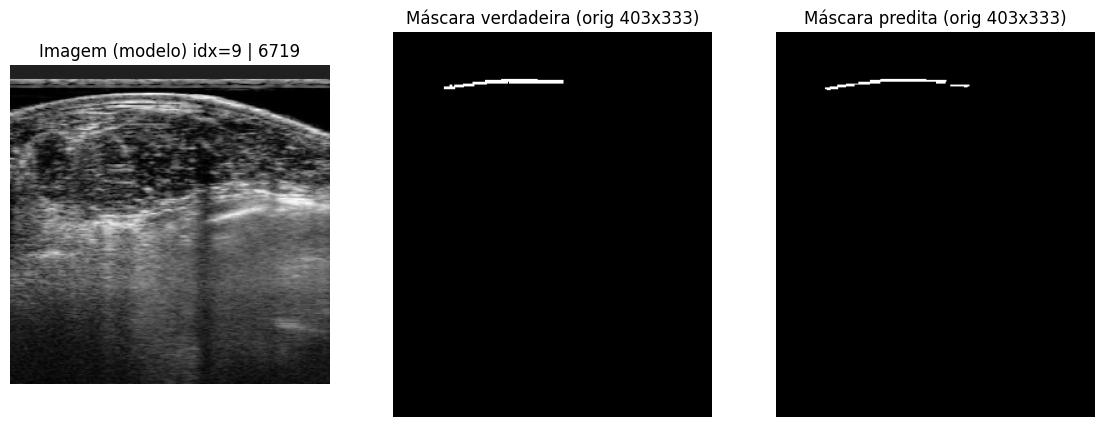

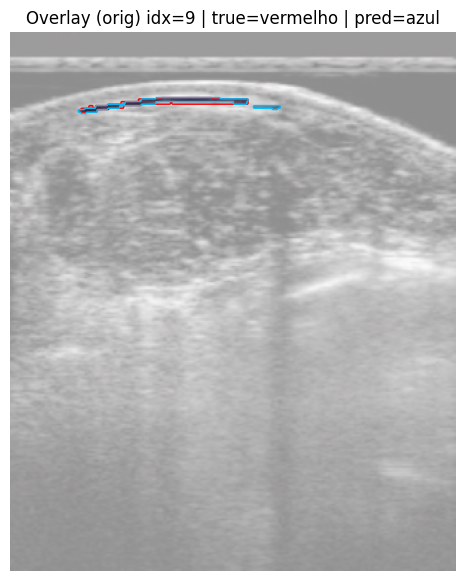

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | 


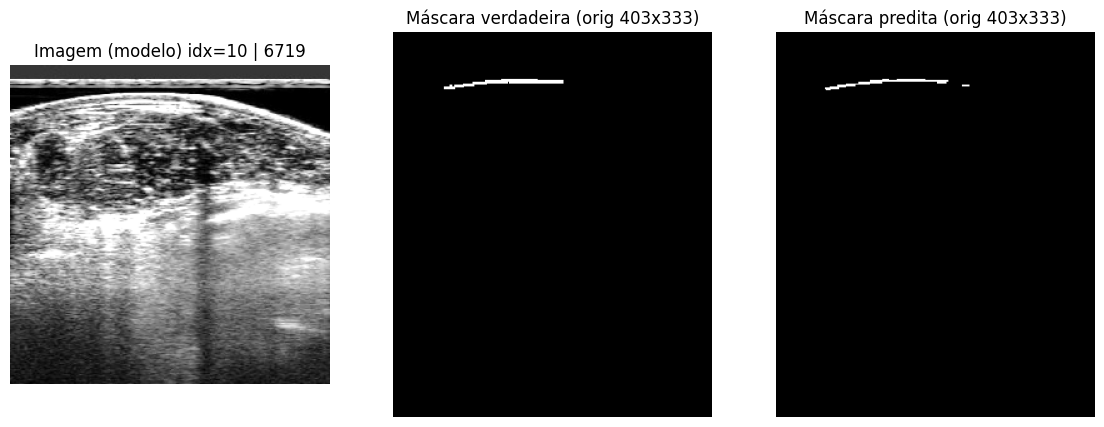

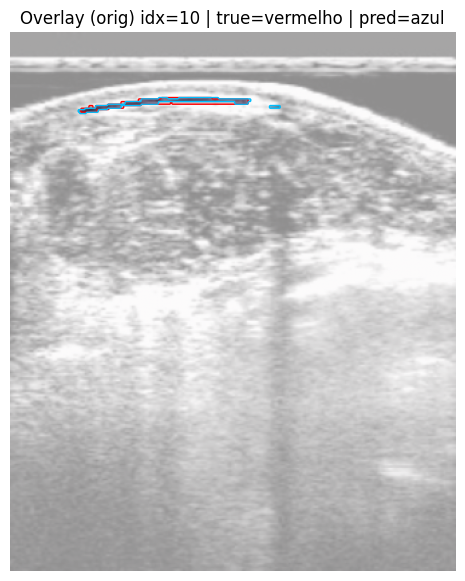

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | 


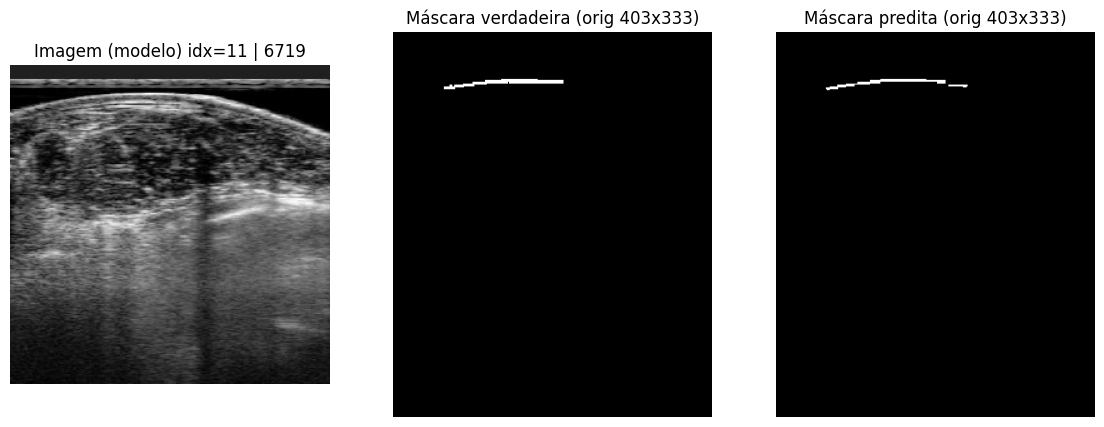

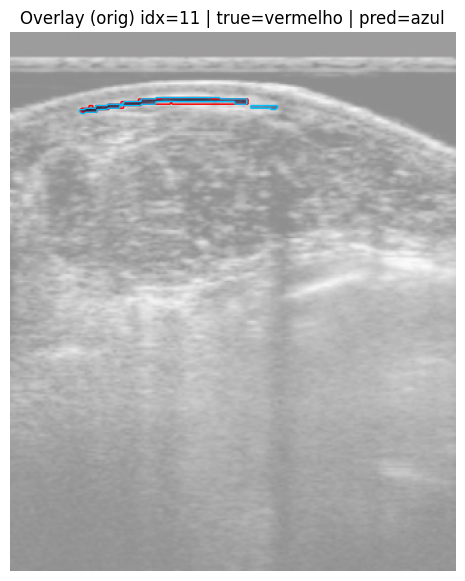

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | 


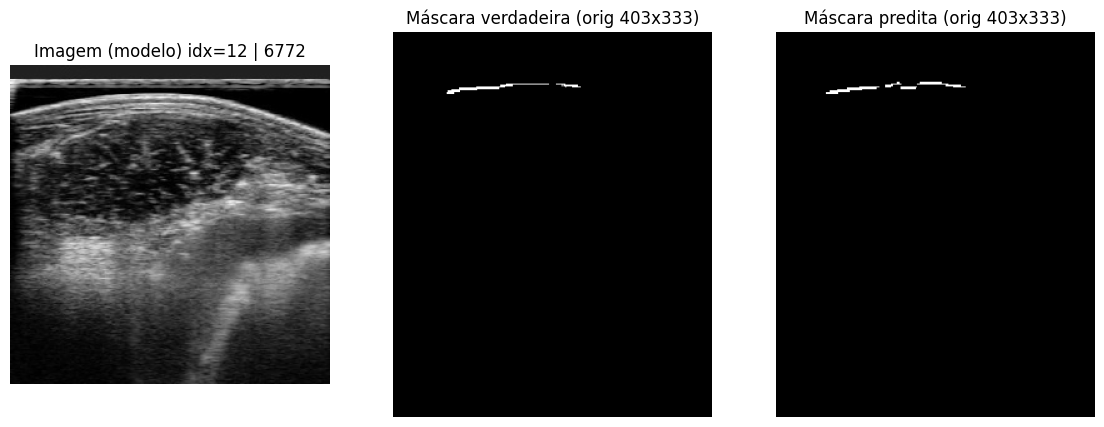

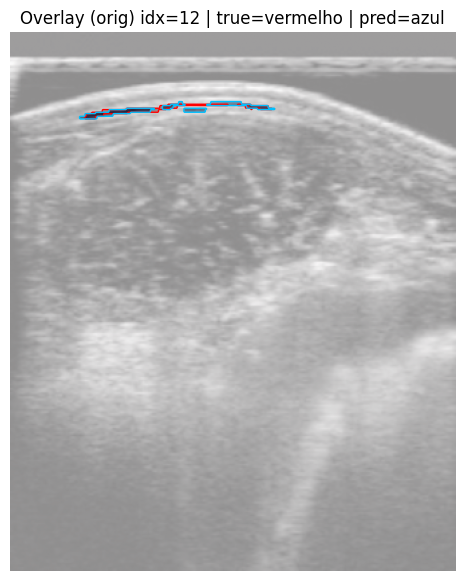

diam_true=0.208 cm | diam_pred=0.208 cm | diam_diff=+0.000 cm | 


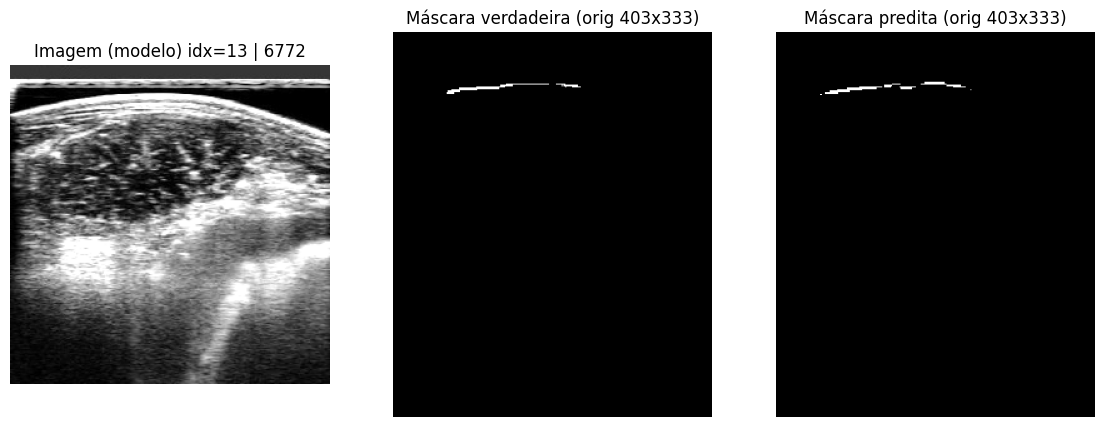

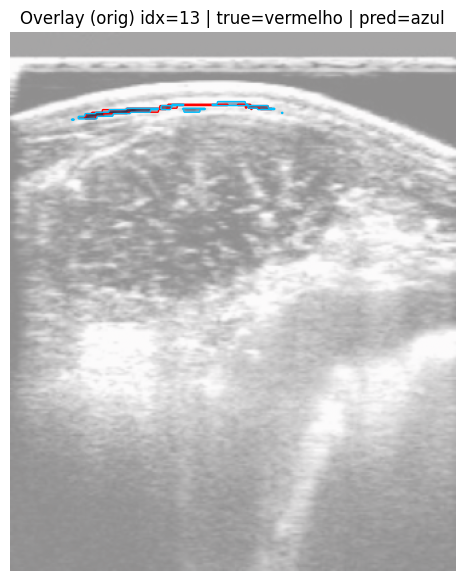

In [37]:
for idx in range(len(x_new)):
    comparar_area_predicao(
        idx,
        modelo,
        x_new_m,
        y_new_m,
        nomes_dados= y_new_nomes,
        orig_size=(403, 333),
        threshold=0.5,
        px_per_cm=24.05,
        smooth=1e-6,
        plot=True,
        overlay_alpha=0.35,
        contours=True,
        verbose=True,
    )

In [38]:
""" Calculando a média dos erros"""
erros = []
area_real: list[float] = [] 
area_predita: list[float] = []
for idx in range(len(x_new)):
    resultado = comparar_area_predicao(
        idx,
        modelo,
        x_new,
        y_new,
        nomes_dados= None,
        orig_size=(105, 213),
        threshold=0.5,
        px_per_cm=24.05,
        smooth=1e-6,
        plot=False,
        overlay_alpha=0.35,
        contours=True,
        verbose=False,
    )
    erros.append(resultado['diam_diff_cm'])
    area_real.append(resultado['diam_true_cm'])
    area_predita.append(resultado['diam_pred_cm'])

In [39]:
# Print dos erros
print(f'Erro médio na validação: {np.mean(np.abs(erros)):.3f} cm')
print(f'Erro Máximo na validação: {np.max(np.abs(erros)):.3f} cm')
print(f'Erro mínimo na validação: {np.min(np.abs(erros)):.3f} cm')

Erro médio na validação: 0.009 cm
Erro Máximo na validação: 0.042 cm
Erro mínimo na validação: 0.000 cm
